In [1]:
# Install recommended transformers version and other dependencies
%pip install --upgrade pandas unsloth transformers==4.56.0 peft bitsandbytes accelerate safetensors trl datasets matplotlib

  Using cached trl-0.29.0-py3-none-any.whl.metadata (11 kB)
  Using cached datasets-4.6.1-py3-none-any.whl.metadata (19 kB)
  Using cached trl-0.24.0-py3-none-any.whl.metadata (11 kB)
INFO: pip is looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
  Using cached trl-0.23.1-py3-none-any.whl.metadata (11 kB)
  Using cached trl-0.23.0-py3-none-any.whl.metadata (11 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
from unsloth import is_bfloat16_supported
import pandas as pd
from datasets import load_dataset
import re
import unicodedata

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
# Load main training data
train_ds = pd.read_csv(
    "../../competitions/deep-past-initiative-machine-translation/train.csv"
)
test_ds = pd.read_csv(
    "../../competitions/deep-past-initiative-machine-translation/test.csv"
)

# Load additional dataset from Hugging Face for training
hf_ds = load_dataset("phucthaiv02/akkadian-translation", split="train").to_pandas()  # type: ignore
# Keep only relevant columns
hf_ds = hf_ds[["translation", "transliteration"]]  # type: ignore

# Competition train.csv will be the validation set
val_full_ds = train_ds.drop_duplicates(
    subset=["translation", "transliteration"]
).reset_index(drop=True)

# HF dataset will be the training set
train_full_ds = hf_ds.drop_duplicates(
    subset=["translation", "transliteration"]
).reset_index(drop=True)

# Ensure no overlap: drop any (translation, transliteration) pairs from train that exist in val
train_full_ds = train_full_ds.merge(
    val_full_ds[["translation", "transliteration"]],
    on=["translation", "transliteration"],
    how="left",
    indicator=True,
)
train_full_ds = (
    train_full_ds[train_full_ds["_merge"] == "left_only"]
    .drop(columns=["_merge"])
    .reset_index(drop=True)
)

print(f"Validation dataset size (Competition Train): {len(val_full_ds)}")
print(f"Training dataset size (HF) after removing overlaps: {len(train_full_ds)}")

train_full_ds.to_csv("merged_train.csv", index=False)
train_full_ds.head()

Validation dataset size (Competition Train): 1561
Training dataset size (HF) after removing overlaps: 72653


,translation,transliteration
0,"You are my father, please",abi atta
1,"You are my brother, please",ahi atta
2,"The year is its year, the year is suitable.",gattum ianat
3,Buy as if you were buying for yourself,kima arramânâtika tasâ'umu sâm
4,"You are my children, please, I beg you",mer'uia attunu


In [4]:
def normalize_transliteration(text):
    if not isinstance(text, str):
        return ""

    # Lowercase everything
    text = text.lower()

    # Map special Akkadian symbols to plain ASCII-ish consistently
    replacements = {
        "š": "sh",
        "sz": "sh",
        "ṣ": "s.",
        "s,": "s.",
        "ṭ": "t.",
        "t,": "t.",
        "ḫ": "h.",
        "h,": "h.",
        "ĝ": "g.",
        "g,": "g.",
        "ā": "a",
        "ē": "e",
        "ī": "i",
        "ū": "u",
        "é": "e",
        "í": "i",
        "ú": "u",
        "á": "a",
        "â": "a",
        "à": "a",
        "è": "e",
        "ì": "i",
        "ù": "u",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    # Standardize broken-text markers and special symbols
    text = re.sub(r"\[\.\.\.\]", "...", text)
    text = re.sub(r"\[|\]", "", text)
    text = re.sub(r"\(|\)", "", text)
    text = re.sub(r"\{.*?\}", "", text)
    text = re.sub(r"\^", "", text)
    text = re.sub(r"<{2,}", "<", text)
    text = re.sub(r">{2,}", ">", text)

    # Normalize subscripts
    text = unicodedata.normalize("NFKC", text)

    # Standardize separators: treat dot as separator and then remove all hyphens
    text = text.replace(".", "-")
    text = text.replace("-", "")

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


# Apply normalization
train_full_ds["transliteration"] = train_full_ds["transliteration"].apply(
    normalize_transliteration
)
val_full_ds["transliteration"] = val_full_ds["transliteration"].apply(
    normalize_transliteration
)
test_ds["transliteration"] = test_ds["transliteration"].apply(normalize_transliteration)

# Deduplicate after normalization
train_full_ds = train_full_ds.drop_duplicates(
    subset=["translation", "transliteration"]
).reset_index(drop=True)
val_full_ds = val_full_ds.drop_duplicates(
    subset=["translation", "transliteration"]
).reset_index(drop=True)

Max lengths after normalization:
Max train input length: 1158
Max train target length: 771
Max validation input length: 3995
Max validation target length: 848


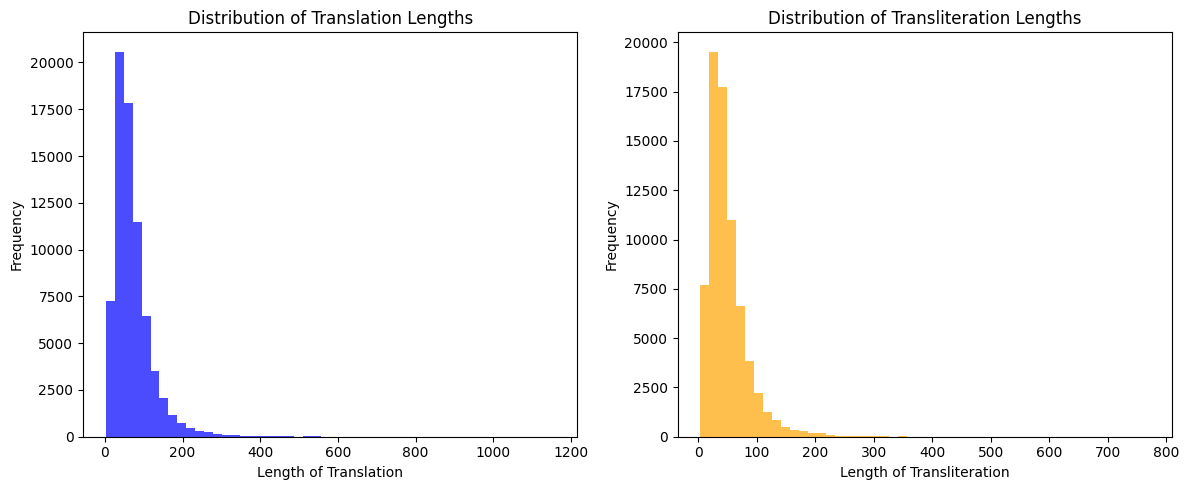

In [5]:
# Max Lengths for model input and output
print("Max lengths after normalization:")

max_train_input_length = max(train_full_ds["translation"].apply(lambda x: len(x)))
max_train_target_length = max(train_full_ds["transliteration"].apply(lambda x: len(x)))

print(f"Max train input length: {max_train_input_length}")
print(f"Max train target length: {max_train_target_length}")

max_val_input_length = max(val_full_ds["translation"].apply(lambda x: len(x)))
max_val_target_length = max(val_full_ds["transliteration"].apply(lambda x: len(x)))

print(f"Max validation input length: {max_val_input_length}")
print(f"Max validation target length: {max_val_target_length}")

import matplotlib.pyplot as plt

# Plot histograms of input and target lengths
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(
    train_full_ds["translation"].apply(lambda x: len(x)),
    bins=50,
    color="blue",
    alpha=0.7,
)
plt.title("Distribution of Translation Lengths")
plt.xlabel("Length of Translation")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(
    train_full_ds["transliteration"].apply(lambda x: len(x)),
    bins=50,
    color="orange",
    alpha=0.7,
)
plt.title("Distribution of Transliteration Lengths")
plt.xlabel("Length of Transliteration")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [6]:
max_input_length = 192
max_target_length = 192

train_full_ds = train_full_ds[
    train_full_ds["transliteration"].apply(lambda x: len(x)) <= max_input_length
]
train_full_ds = train_full_ds[
    train_full_ds["translation"].apply(lambda x: len(x)) <= max_target_length
]


print(f"Final training size: {len(train_full_ds)}")
print(f"Final validation size: {len(val_full_ds)}")
train_full_ds.to_csv("merged_train_normalized.csv", index=False)
train_full_ds.head()

Final training size: 70523
Final validation size: 1561


,translation,transliteration
0,"You are my father, please",abi atta
1,"You are my brother, please",ahi atta
2,"The year is its year, the year is suitable.",gattum ianat
3,Buy as if you were buying for yourself,kima arramanatika tasa'umu sam
4,"You are my children, please, I beg you",mer'uia attunu


In [ ]:
from unsloth import FastLanguageModel
import torch
from datasets import Dataset
import os
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForLanguageModeling

# Using Tencent's Hunyuan-MT-1.8B through Unsloth
model_name = "tencent/HY-MT1.5-1.8B"

max_seq_length = max_input_length + max_target_length + 32
dtype = (
    torch.bfloat16
)  # A100 natively supports BF16 for better precision and efficiency

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=True,
    full_finetuning=False,
    trust_remote_code=True,
)

# Apply LoRA for better stability and lower memory usage even on A100
r = 32
model = FastLanguageModel.get_peft_model(
    model,
    r=r,
    task_type="CAUSAL_LM",
    target_modules="all-linear",  # LoRA on all linear layers for better performance on complex tasks
    lora_alpha=r * 2,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=0,
)


# 2. Data Preparation for Hunyuan-MT SFT
def formatting_prompts_func(examples):
    inputs = examples["transliteration"]
    outputs = examples["translation"]
    texts = []
    for input_text, output_text in zip(inputs, outputs):
        messages = [
            {
                "role": "user",
                "content": f"Translate the following segment into English, without additional explanation.\n\n{input_text}",
            },
            {"role": "assistant", "content": output_text},
        ]
        tokenized_chat = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        texts.append(tokenized_chat)
    return {
        "text": texts,
    }


train_dataset = Dataset.from_pandas(train_full_ds)
val_dataset = Dataset.from_pandas(val_full_ds)

train_dataset = train_dataset.map(
    formatting_prompts_func,
    batched=True,
    num_proc=os.cpu_count(),
)
val_dataset = val_dataset.map(
    formatting_prompts_func,
    batched=True,
    num_proc=os.cpu_count(),
)

# Use standard DataCollatorForLanguageModeling since DataCollatorForCompletionOnlyLM is missing
collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# 3. Training
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    data_collator=collator,
    dataset_num_proc=os.cpu_count(),
    packing=True,  # Re-enable packing for speed since we're using standard collator
    args=TrainingArguments(
        per_device_train_batch_size=8,
        gradient_accumulation_steps=4,
        warmup_steps=100,
        learning_rate=2e-5,
        num_train_epochs=3,
        fp16=False,
        bf16=True,
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        seed=0,
        output_dir="outputs",
        report_to="none",
        eval_strategy="steps",
        eval_steps=250,
        save_steps=500,
    ),
)

trainer_stats = trainer.train()

Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.3.3: Fast Hunyuan_V1_Dense patching. Transformers: 4.56.0.
   \\   /|    NVIDIA A100 80GB PCIe. Num GPUs = 1. Max memory: 79.254 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Making `model.base_model.model.model` require gradients


Map (num_proc=32):   0%|          | 0/70523 [00:00<?, ? examples/s]

Map (num_proc=32):   0%|          | 0/1561 [00:00<?, ? examples/s]

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=36):   0%|          | 0/70523 [00:00<?, ? examples/s]

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=36):   0%|          | 0/1561 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss
250,2.233700,2.276527
500,1.851400,2.272821
750,1.291500,2.265947
1000,1.172500,2.323940


Unsloth: Not an error, but HunYuanDenseV1ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


In [11]:
import json
import shutil
from pathlib import Path

# Create a model checkpoint directory
model_dir = Path("hunyuan_mt_lora_model_final")
model_dir.mkdir(exist_ok=True)

# 1. Save the trained PEFT model and tokenizer
print("Saving PEFT model and tokenizer...")
model.save_pretrained(str(model_dir))
tokenizer.save_pretrained(str(model_dir))
print(f"✓ Model and tokenizer saved to {model_dir}")

# 2. Save training statistics
print("\nSaving training statistics...")
training_stats = {
    "model_name": model_name,
    "training_dataset_size": len(train_full_ds),
    "validation_dataset_size": len(val_full_ds),
    "max_seq_length": max_seq_length,
    "lora_r": r,
    "lora_alpha": r * 2,
    "learning_rate": trainer.args.learning_rate,
    "batch_size": trainer.args.per_device_train_batch_size,
    "gradient_accumulation_steps": trainer.args.gradient_accumulation_steps,
    "num_train_epochs": trainer.args.num_train_epochs,
    "total_training_steps": trainer.state.global_step,
}

# Save to JSON
with open(model_dir / "training_config.json", "w") as f:
    json.dump(training_stats, f, indent=2)
print(f"✓ Training config saved to {model_dir}/training_config.json")

# 3. Save training metrics if available
if hasattr(trainer, "state") and hasattr(trainer.state, "log_history"):
    metrics_df = pd.DataFrame(trainer.state.log_history)
    metrics_csv = model_dir / "training_metrics.csv"
    metrics_df.to_csv(metrics_csv, index=False)
    print(f"✓ Training metrics saved to {metrics_csv}")

# 4. Copy training output directory to model directory
if os.path.exists("outputs"):
    shutil.copytree("outputs", str(model_dir / "checkpoints"), dirs_exist_ok=True)
    print(f"✓ Checkpoints copied to {model_dir}/checkpoints")

# 5. Create a summary file
summary_text = f"""# Hunyuan-MT Akkadian-to-English Translation Model - Final Checkpoint

## Model Information
- **Base Model**: {model_name}
- **Fine-tuning Method**: LoRA (r={r}, alpha={r*2})
- **Framework**: Unsloth + Transformers + TRL

## Dataset Statistics
- **Training Samples**: {len(train_full_ds):,}
- **Validation Samples**: {len(val_full_ds):,}
- **Input Length Limit**: {max_input_length} characters
- **Target Length Limit**: {max_target_length} characters

## Training Configuration
- **Learning Rate**: 2e-5
- **Batch Size**: 8 (per device)
- **Gradient Accumulation Steps**: 4
- **Effective Batch Size**: 32
- **Max Sequence Length**: {max_seq_length}
- **Optimizer**: adamw_8bit
- **LR Scheduler**: cosine
- **Total Training Steps**: {trainer.state.global_step}

## Model Structure
The model uses LoRA adapters applied to all linear layers for efficient fine-tuning.
To use this model:

```python
from unsloth import FastLanguageModel
from peft import AutoPeftModelForCausalLM, AutoPeftModelForSeq2SeqLM

# Load the PEFT model
model = AutoPeftModelForCausalLM.from_pretrained(
    "hunyuan_mt_lora_model_final",
    load_in_4bit=True,
)
tokenizer = AutoTokenizer.from_pretrained("hunyuan_mt_lora_model_final")

# For inference
from unsloth import FastLanguageModel
FastLanguageModel.for_inference(model)
```

## Inference Example

```python
messages = [
    {{
        "role": "user",
        "content": "Translate the following segment into English, without additional explanation.\\n\\n[YOUR_AKKADIAN_TEXT_HERE]",
    }},
]

inputs = tokenizer.apply_chat_template(
    messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

outputs = model.generate(
    input_ids=inputs,
    max_new_tokens=256,
    use_cache=True,
    top_k=20,
    top_p=0.6,
    temperature=0.7,
    do_sample=True,
)

translation = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)
```

## Files in This Directory
- `adapter_config.json`: LoRA configuration
- `adapter_model.safetensors`: LoRA weights
- `config.json`: Model configuration
- `generation_config.json`: Generation default parameters
- `tokenizer.json`: Tokenizer
- `tokenizer_config.json`: Tokenizer configuration
- `training_config.json`: Training hyperparameters
- `training_metrics.csv`: Training and validation loss per step
- `checkpoints/`: All intermediate checkpoints from training

## Training Notes
- The model was trained using the Unsloth library for efficient LoRA fine-tuning
- BF16 (bfloat16) precision was used on A100 GPU for memory efficiency
- Packing was enabled to speed up training
- Sequence length includes both instruction and completion tokens
"""

summary_path = model_dir / "README.md"
with open(summary_path, "w") as f:
    f.write(summary_text)
print(f"✓ Summary saved to {summary_path}")

# 6. Verify saved files
print("\n" + "=" * 60)
print("FINAL MODEL CHECKPOINT SAVED")
print("=" * 60)
print(f"Location: {model_dir.resolve()}")
print(f"\nTotal training steps completed: {trainer.state.global_step}")
print(f"Model size: {sum(p.numel() for p in model.parameters()):,} parameters")

# List all files in the model directory
print("\nSaved files:")
for file_path in sorted(model_dir.glob("**/*")):
    if file_path.is_file():
        file_size = file_path.stat().st_size / (1024 * 1024)  # Convert to MB
        print(f"  - {file_path.relative_to(model_dir)} ({file_size:.2f} MB)")

print("\n✓ All training artifacts saved successfully!")

Repo card metadata block was not found. Setting CardData to empty.
[huggingface_hub.repocard|WARNING]Repo card metadata block was not found. Setting CardData to empty.


Saving PEFT model and tokenizer...
✓ Model and tokenizer saved to hunyuan_mt_lora_model_final

Saving training statistics...
✓ Training config saved to hunyuan_mt_lora_model_final/training_config.json
✓ Training metrics saved to hunyuan_mt_lora_model_final/training_metrics.csv
✓ Checkpoints copied to hunyuan_mt_lora_model_final/checkpoints
✓ Summary saved to hunyuan_mt_lora_model_final/README.md

FINAL MODEL CHECKPOINT SAVED
Location: /home/iato/code/Akkadian/remote_notebooks/sfisaact__notebook78aec80886/hunyuan_mt_lora_model_final

Total training steps completed: 1104
Model size: 1,058,125,824 parameters

Saved files:
  - README.md (0.00 MB)
  - adapter_config.json (0.00 MB)
  - adapter_model.safetensors (148.06 MB)
  - chat_template.jinja (0.00 MB)
  - checkpoints/README.md (0.00 MB)
  - checkpoints/checkpoint-1000/README.md (0.00 MB)
  - checkpoints/checkpoint-1000/adapter_config.json (0.00 MB)
  - checkpoints/checkpoint-1000/adapter_model.safetensors (148.06 MB)
  - checkpoints/che

In [ ]:
from tqdm.auto import tqdm
import torch
from peft import AutoPeftModelForCausalLM
from transformers import AutoTokenizer
import pandas as pd

test_ds = pd.read_csv(
    "/kaggle/input/competitions/deep-past-initiative-machine-translation/test.csv"
)

# Path to trained LoRA model
model_path = "hunyuan_mt_lora_model_final"

print("Loading trained model from checkpoint...")

# Load model
model = AutoPeftModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
    load_in_4bit=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

model.eval()

print("Model loaded successfully!")


# Translation function
def translate_akkadian(transliteration, model=model, tokenizer=tokenizer):
    messages = [
        {
            "role": "user",
            "content": f"Translate the following segment into English, without additional explanation.\n\n{transliteration}",
        },
    ]

    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs,
            max_new_tokens=256,
            top_k=20,
            top_p=0.6,
            repetition_penalty=1.05,
            temperature=0.7,
            do_sample=True,
            use_cache=True,
            eos_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(outputs[0][inputs.shape[1] :], skip_special_tokens=True)

    return decoded.strip()


# Run inference
print("\nRunning inference on test dataset...")
translations = []
test_transliterations = test_ds["transliteration"].tolist()

print(f"Processing {len(test_transliterations)} samples...")

for translit in tqdm(test_transliterations):
    translations.append(translate_akkadian(translit))

test_ds["translation"] = translations

# Save results
test_ds.to_csv("test_predictions_hunyuan_mt.csv", index=False)

print("✓ Saved predictions to test_predictions_hunyuan_mt.csv")
print("\nSample predictions:")
print(test_ds.head())

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading trained model from checkpoint...
Model loaded successfully!

Running inference on test dataset...
Processing 4 samples...


  0%|          | 0/4 [00:00<?, ?it/s]

✓ Saved predictions to test_predictions_hunyuan_mt.csv

Sample predictions:


,id,text_id,line_start,line_end,transliteration,translation
0,0,332fda50,1,7,umma karuum kaniiama ana aaqiil datim aiiprini...,"Thus (said) the Kanish colony, speak to the da..."
1,1,332fda50,7,14,ina muppiim aa alimki iatu u„miim anim mamaan ...,"On the basis of the tablet of the City, from t..."
2,2,332fda50,14,24,kima muppini taaameani amakam lu ana aimiim an...,"As soon as you hear our letter, give it either..."
3,3,332fda50,25,30,me+eer muppini ana kaar kaarma u wabarratim ae...,The copy of our tablet was sent to every singl...
